# B-3001 · Modelo baseline y proyección de daño

Consume `features/b3001_panel.parquet`, que produce **`B3001_features_v2.ipynb`**. Este
notebook no recalcula features: si falta una, se agrega allá y se vuelve a exportar.

**La pregunta:** ¿el B-3001 se detiene o no en **octubre de 2028**?

**Qué puede y qué no puede un modelo de árboles acá.** Conviene ser explícito desde el arranque:

- RF y XGBoost **no extrapolan 2,7 años**. Son modelos de horizonte corto: entrenados sobre
  features horarias predicen a 24 h o a 30 d, no a 2028.
- Lo que sí hacen es **estimar la tasa de daño con la que el horno opera hoy**. Esa tasa es el
  insumo de la proyección, que es un paso aparte (sección 6) y es aritmética de fluencia, no
  aprendizaje automático.

Por eso hay **dos objetivos**, y el importante es el primero:

| Objetivo | Columna | Baseline ingenuo | Por qué |
|---|---|---|---|
| **Daño a 30 d** | `target_dose_30d` | `thermal_dose_30d` (la dosis de los 30 d previos) | es literalmente "estimación del daño"; alimenta la proyección a 2028 |
| Temperatura a 24 h | `target_T_24h` | `lag_24h` (persistencia) | el problema clásico; mide si las features capturan la dinámica térmica |

**Estructura:** 1 entorno · 2 datos · 3 corte temporal · 4 casos de features · 5 entrenamiento
· 6 proyección a 2028 · 7 lectura. Corre en ~4 min.

## 1. Entorno

In [1]:
import importlib, subprocess, sys
for pkg in ["pyarrow", "xgboost", "scikit-learn"]:
    if importlib.util.find_spec(pkg.replace("-", "_").replace("scikit_learn", "sklearn")) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import time
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 80)

COLOR_PASO = {"P1": "#2a78d6", "P2": "#eb6834", "P3": "#1baf7a", "P4": "#eda100"}
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
SUP, TINTA, TINTA2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "figure.facecolor": SUP, "axes.facecolor": SUP,
    "text.color": TINTA, "axes.labelcolor": TINTA2, "xtick.color": TINTA2,
    "ytick.color": TINTA2, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


## 2. Datos

Se levanta el panel (nivel tubo, con paso y horno unidos) y la tabla de horno, que aporta la
disponibilidad operativa que usa la proyección.

Las constantes de fluencia se redeclaran acá porque la proyección de la sección 6 las necesita.
Para que no se desincronicen con las de la Parte I, la celda **verifica** que el
`thermal_dose_1h` recalculado con estas constantes reproduzca el que viene en el parquet. Si
cambiaste el modelo de creep allá y no acá, la celda falla en vez de proyectar con números
mezclados.

In [2]:
from pathlib import Path

BASE     = Path.cwd()
FEATURES = BASE / "features"
REPORTES = BASE / "reportes"
REPORTES.mkdir(parents=True, exist_ok=True)

PANEL = FEATURES / "b3001_panel.parquet"
HORNO = FEATURES / "b3001_nivel3_horno.parquet"
assert PANEL.exists(), f"Falta {PANEL}. Correr antes B3001_features_v2.ipynb (sección 15)."

panel  = pd.read_parquet(PANEL)
nivel3 = pd.read_parquet(HORNO)

# ---------- constantes de fluencia (deben coincidir con la Parte I) ----------
CLM           = 20.946
TMT_DISENO    = 705.0
DO, T_PROM    = 108.0, 12.1
P_MPA         = 57.2 * 0.0981
VIDA_DISENO_H = 100_000.0
SIGMA_H   = (P_MPA * (DO - T_PROM)) / (2 * T_PROM)
LMP_SIGMA = (TMT_DISENO + 273.15) * (CLM + np.log10(VIDA_DISENO_H)) / 1000

def t_ruptura(T_c):
    """t_r(T) a sigma_h por Larson-Miller, anclado a 705 °C / 100.000 h (API 530, SI)."""
    return 10 ** (LMP_SIGMA * 1000 / (np.asarray(T_c, dtype="float64") + 273.15) - CLM)

# la jerarquía se lee del propio panel, no se vuelve a declarar
TUBO_PASO = panel.groupby("tubo", observed=True).paso.first().to_dict()
PASOS     = sorted(panel.paso.unique())
TUBOS     = sorted(TUBO_PASO)

# ---------- verificación de consistencia con la Parte I ----------
chk = panel[(panel.run == 1) & (panel.valido == 1) & (panel.sat == 0)].dropna(
    subset=["temperatura", "thermal_dose_1h"]).sample(5000, random_state=0)
assert np.allclose(1.0 / t_ruptura(chk.temperatura), chk.thermal_dose_1h, rtol=1e-3), \
    "Las constantes de creep no coinciden con las que generaron el panel."

print(f"panel  : {panel.shape[0]:>9,} x {panel.shape[1]:<3}  "
      f"{panel.ts.min():%Y-%m-%d} -> {panel.ts.max():%Y-%m-%d}")
print(f"nivel3 : {nivel3.shape[0]:>9,} x {nivel3.shape[1]:<3}")
print(f"jerarquía: {len(PASOS)} pasos · {len(TUBOS)} tubos")
print(f"sigma_h = {SIGMA_H:.2f} MPa | LMP_sigma = {LMP_SIGMA:.4f}  ✓ consistente con el panel")

panel  : 1,121,832 x 65   2020-10-01 -> 2026-01-30
nivel3 :    46,743 x 16 
jerarquía: 4 pasos · 24 tubos
sigma_h = 22.24 MPa | LMP_sigma = 25.3791  ✓ consistente con el panel


## 3. Corte temporal

Train 2020-10 → 2024-10, test 2025-01 → último dato. El hueco de oct-dic 2024 es un
**embargo**: separa train de test para que las ventanas móviles de 30 d y los targets a +24 h /
+30 d de las últimas filas de train no toquen el período de test.

Solo entran filas con `run == 1` y `valido == 1`: horno en operación y termopar sano. Sin el
segundo filtro el modelo aprende que un tubo puede estar a 250 °C con el horno encendido.

In [3]:
# ---------------- configuración editable ----------------
TRAIN_INI, TRAIN_FIN = pd.Timestamp("2020-10-01"), pd.Timestamp("2024-10-01")
TEST_INI             = pd.Timestamp("2025-01-01")
SUBM    = 4      # usa 1 de cada N horas del train (1 = todo, más lento)
SEMILLA = 0

# el panel tiene que cubrir el train: si no, mover DATA_START en B3001_features_v2 (celda 6)
assert panel.ts.min() <= TRAIN_INI, (
    f"El panel arranca en {panel.ts.min():%Y-%m-%d} y el train pide {TRAIN_INI:%Y-%m-%d}. "
    f"Bajar DATA_START en B3001_features_v2.ipynb y reexportar.")

usable = panel[(panel.run == 1) & (panel.valido == 1)].copy()
for c in ("tubo", "paso", "elev", "cara"):          # categóricas -> códigos para los árboles
    usable[c + "_cod"] = usable[c].astype("category").cat.codes

tr = usable[(usable.ts >= TRAIN_INI) & (usable.ts < TRAIN_FIN)]
te = usable[usable.ts >= TEST_INI]

print(f"train : {TRAIN_INI:%Y-%m} -> {TRAIN_FIN:%Y-%m}   {len(tr):>9,} filas "
      f"({len(tr)//SUBM:,} tras submuestreo 1/{SUBM})")
print(f"test  : {TEST_INI:%Y-%m} -> {te.ts.max():%Y-%m}   {len(te):>9,} filas")
print(f"embargo: {TRAIN_FIN:%Y-%m-%d} -> {TEST_INI:%Y-%m-%d} "
      f"({(TEST_INI-TRAIN_FIN).days} días descartados)")
print(f"descartado por run/valido: {(1-len(usable)/len(panel))*100:.1f}% del panel")

train : 2020-10 -> 2024-10     606,004 filas (151,501 tras submuestreo 1/4)
test  : 2025-01 -> 2026-01     143,880 filas
embargo: 2024-10-01 -> 2025-01-01 (92 días descartados)
descartado por run/valido: 29.8% del panel


In [4]:
MODELOS = {
    "RF":  lambda: RandomForestRegressor(n_estimators=150, min_samples_leaf=50,
                                         max_features="sqrt", n_jobs=-1, random_state=SEMILLA),
    "XGB": lambda: XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                random_state=SEMILLA, tree_method="hist"),
}

# objetivo -> (columna a predecir, baseline ingenuo, unidad, ¿se recorta en 0?)
OBJETIVOS = {
    "dano_30d": ("target_dose_30d", "thermal_dose_30d", "daño (adim)", True),
    "T_24h":    ("target_T_24h",    "lag_24h",          "°C",          False),
}
for o, (col, base, uni, _) in OBJETIVOS.items():
    print(f"  {o:<10} -> {col:<17} baseline {base:<18} "
          f"train {tr[col].notna().sum():>8,} | test {te[col].notna().sum():>8,}")

  dano_30d   -> target_dose_30d   baseline thermal_dose_30d   train  606,004 | test  137,597
  T_24h      -> target_T_24h      baseline lag_24h            train  601,807 | test  142,098


## 4. Casos de prueba · qué features se le dan al modelo

Siete combinaciones, de la más pobre a la más rica, más dos diagnósticas. Cada una responde
una pregunta concreta; comparar sus métricas es lo que dice qué nivel de la jerarquía aporta.

| Caso | Qué contiene | Qué pregunta responde |
|---|---|---|
| `C1_min_fisico` | las 6 features del nivel 1 en su versión mínima | ¿alcanza con la física básica del tubo? |
| `C2_nivel1` | todo el nivel 1 (sin acumuladas) | ¿cuánto suma el resto del nivel tubo? |
| `C3_nivel1_2` | nivel 1 + nivel 2 | ¿el contexto del paso mejora la predicción del tubo? |
| `C4_todo` | niveles 1 + 2 + 3 + posición | ¿el estado global del horno agrega algo? |
| `C5_sin_nivel_termico` | `C4` sin temperatura ni sus derivados de nivel | ¿hay señal más allá de "está caliente"? |
| `C6_solo_paso_horno` | solo niveles 2 y 3 | ¿se puede predecir un tubo sin medirlo? (útil si su sensor falla) |
| `C7_con_acumuladas` | `C4` + `exposure` + `thermal_dose` | **diagnóstico**: muestra el daño de meter acumuladas |

`C7` está para demostrar un problema, no para ganar: `exposure` y `thermal_dose` crecen
monótonamente, así que en el test toman valores que **nunca aparecieron en train**. Un árbol no
extrapola: corta en el último umbral que vio y predice constante de ahí en adelante. Si `C7`
empeora respecto de `C4`, esa es la razón.

`thermal_dose_1h` queda excluida de todos los casos: es función determinística de
`temperatura` (ρ = 1.00), meterla sería duplicar la misma columna.

In [5]:
N1 = ["temperatura","slope","slope_24h","delta","delta_24h","delta_z_30d","exposure_30d",
      "thermal_dose_30d","rank","rank_horno","persistence","persistence_rank1","hot",
      "sensor_health_30d","h_desde_arranque","hora"]
N2 = ["paso_mean","paso_max","paso_std","paso_spread","paso_cv","paso_n_hot_tubes",
      "paso_hot_tube_slope","paso_conv","paso_ctrl","paso_delta_ctrl"]
N3 = ["horno_global_max","horno_global_p95","horno_global_spread","horno_pass_gradient",
      "horno_critical_pass_persistence","horno_global_slope","horno_global_instability",
      "horno_n_hot_tubes"]
POS  = ["elev_cod","cara_cod"]
ACUM = ["exposure","thermal_dose"]                    # acumuladas: rompen la extrapolación
TERMICO = {"temperatura","paso_mean","paso_max","horno_global_max","horno_global_p95"}

CASOS = {
    "C1_min_fisico":        ["temperatura","slope","delta","rank","persistence","exposure_30d"],
    "C2_nivel1":            N1,
    "C3_nivel1_2":          N1 + N2,
    "C4_todo":              N1 + N2 + N3 + POS,
    "C5_sin_nivel_termico": [f for f in N1 + N2 + N3 + POS if f not in TERMICO],
    "C6_solo_paso_horno":   N2 + N3,
    "C7_con_acumuladas":    N1 + N2 + N3 + POS + ACUM,
}
for k, v in CASOS.items():
    print(f"  {k:<22} {len(v):>2} features")

  C1_min_fisico           6 features
  C2_nivel1              16 features
  C3_nivel1_2            26 features
  C4_todo                36 features
  C5_sin_nivel_termico   31 features
  C6_solo_paso_horno     18 features
  C7_con_acumuladas      38 features


## 5. Entrenamiento y comparación

`mejora_%` es la reducción de MAE respecto del baseline ingenuo del objetivo. **Es la única
columna que importa**: un MAE bajo en términos absolutos no dice nada si el baseline trivial lo
consigue igual. Negativo = el modelo es peor que no hacer nada.

In [6]:
AJUSTADOS, PRED = {}, {}

def evaluar(objetivo, casos=CASOS, modelos=MODELOS):
    col, base_col, uni, recorta = OBJETIVOS[objetivo]
    filas = []
    for caso, feats in casos.items():
        f = [c for c in feats if c in usable.columns]
        a = tr.dropna(subset=f + [col]).iloc[::SUBM]
        b = te.dropna(subset=f + [col, base_col])
        ya, yb, base = a[col], b[col], b[base_col]
        if recorta:
            ya, yb = ya.clip(lower=0), yb.clip(lower=0)
        mae_base = mean_absolute_error(yb, base)
        for mod, crear in modelos.items():
            t0 = time.time()
            m = crear().fit(a[f], ya)
            pr = m.predict(b[f])
            if recorta:
                pr = np.clip(pr, 0, None)
            AJUSTADOS[(objetivo, caso, mod)] = (m, f)
            PRED[(objetivo, caso, mod)] = (yb.to_numpy(), pr, base.to_numpy())
            filas.append({"caso": caso, "modelo": mod, "n_feats": len(f),
                          "MAE": mean_absolute_error(yb, pr), "R2": r2_score(yb, pr),
                          "MAE_base": mae_base,
                          "mejora_%": (1 - mean_absolute_error(yb, pr)/mae_base)*100,
                          "seg": time.time() - t0})
    return pd.DataFrame(filas).sort_values("MAE").reset_index(drop=True)

RES = {}
for obj in OBJETIVOS:
    print(f"\n{'='*78}\nOBJETIVO: {obj}  ({OBJETIVOS[obj][2]}) — baseline: {OBJETIVOS[obj][1]}\n{'='*78}")
    RES[obj] = evaluar(obj)
    fmt = "{:.3e}".format if obj == "dano_30d" else "{:.2f}".format
    print(RES[obj].to_string(index=False, formatters={"MAE": fmt, "MAE_base": fmt,
                                                      "R2": "{:.3f}".format,
                                                      "mejora_%": "{:+.1f}".format,
                                                      "seg": "{:.1f}".format}))


OBJETIVO: dano_30d  (daño (adim)) — baseline: thermal_dose_30d


                caso modelo  n_feats       MAE     R2  MAE_base mejora_%  seg
       C1_min_fisico    XGB        6 7.890e-05  0.059 9.838e-05    +19.8  0.6
           C2_nivel1     RF       16 7.941e-05  0.053 9.865e-05    +19.5  7.2
         C3_nivel1_2    XGB       26 8.167e-05  0.074 9.872e-05    +17.3  0.9
       C1_min_fisico     RF        6 8.199e-05  0.076 9.838e-05    +16.7  4.1
         C3_nivel1_2     RF       26 8.220e-05  0.087 9.872e-05    +16.7 10.6
             C4_todo     RF       36 8.357e-05  0.081 9.872e-05    +15.3 12.0
C5_sin_nivel_termico     RF       31 8.473e-05  0.075 9.872e-05    +14.2  9.6
           C2_nivel1    XGB       16 8.534e-05 -0.053 9.865e-05    +13.5  0.7
             C4_todo    XGB       36 8.557e-05  0.054 9.872e-05    +13.3  1.1
C5_sin_nivel_termico    XGB       31 8.947e-05  0.020 9.872e-05     +9.4  1.0
   C7_con_acumuladas     RF       38 9.197e-05  0.011 9.872e-05     +6.8 13.3
   C7_con_acumuladas    XGB       38 1.007e-04 -0.217 9.872e-05 

                caso modelo  n_feats   MAE     R2 MAE_base mejora_%  seg
         C3_nivel1_2     RF       26 20.61  0.618    22.10     +6.8  9.4
         C3_nivel1_2    XGB       26 21.36  0.590    22.10     +3.4  2.0
             C4_todo     RF       36 22.03  0.609    22.10     +0.3 12.4
   C7_con_acumuladas     RF       38 22.05  0.613    22.10     +0.3 13.2
       C1_min_fisico     RF        6 22.50  0.585    22.30     -0.9  3.5
           C2_nivel1     RF       16 24.58  0.555    22.35    -10.0  6.3
       C1_min_fisico    XGB        6 25.75  0.390    22.30    -15.5  1.4
C5_sin_nivel_termico     RF       31 26.99  0.570    22.10    -22.1 11.1
           C2_nivel1    XGB       16 28.10  0.446    22.35    -25.8  1.6
             C4_todo    XGB       36 36.10  0.303    22.10    -63.3  2.6
C5_sin_nivel_termico    XGB       31 38.96  0.251    22.10    -76.3  2.3
   C7_con_acumuladas    XGB       38 41.17  0.207    22.10    -86.2  2.6
  C6_solo_paso_horno     RF       18 49.38  0.261  

### 5.1 Por qué cuesta tanto ganarle a la persistencia en `T_24h`

El MAE de ese objetivo no lo fija el régimen normal: lo fijan las maniobras. La tabla de abajo
parte el test según cuánto se movió la temperatura de verdad en esas 24 h.

In [7]:
d = te.dropna(subset=["target_T_24h", "lag_24h"])
cambio = (d.target_T_24h - d.temperatura).abs()
print("descomposición del MAE del baseline por magnitud del cambio real a 24 h:\n")
print(f"{'|ΔT| real':<16}{'% filas':>10}{'MAE baseline':>15}{'aporte al MAE':>16}")
for lo, hi, et in [(0,5,"0-5 °C"), (5,20,"5-20 °C"), (20,100,"20-100 °C"), (100,9e9,">100 °C")]:
    m = (cambio >= lo) & (cambio < hi)
    mae = np.abs(d.lag_24h - d.target_T_24h)[m].mean()
    print(f"{et:<16}{m.mean()*100:>9.1f}%{mae:>15.2f}{mae*m.mean():>16.2f}")
print("\nEl 3% de filas con saltos >100 °C son arranques y paradas: cambios de consigna "
      "operativa,\nno deriva térmica. Ningún modelo alimentado solo con historia térmica los "
      "anticipa, y\nse llevan la mitad del MAE. Es el techo real de este objetivo, no una "
      "falla del modelo.")

descomposición del MAE del baseline por magnitud del cambio real a 24 h:

|ΔT| real          % filas   MAE baseline   aporte al MAE
0-5 °C               62.4%           8.37            5.23
5-20 °C              27.0%          19.72            5.32
20-100 °C             7.5%          52.06            3.90
>100 °C               3.2%         251.99            7.95

El 3% de filas con saltos >100 °C son arranques y paradas: cambios de consigna operativa,
no deriva térmica. Ningún modelo alimentado solo con historia térmica los anticipa, y
se llevan la mitad del MAE. Es el techo real de este objetivo, no una falla del modelo.


## 6. Qué features usa el mejor modelo

Importancia sobre `C4_todo` (el caso que contiene los tres niveles, único donde el desglose
por nivel significa algo). Sirve para podar: si una familia entera aparece con importancia ~0,
se puede sacar del pipeline sin costo.

ganador en MAE : C1_min_fisico / XGB (6 features, +19.8% vs baseline)
caso analizado : C4_todo / RF (36 features, +15.3%)



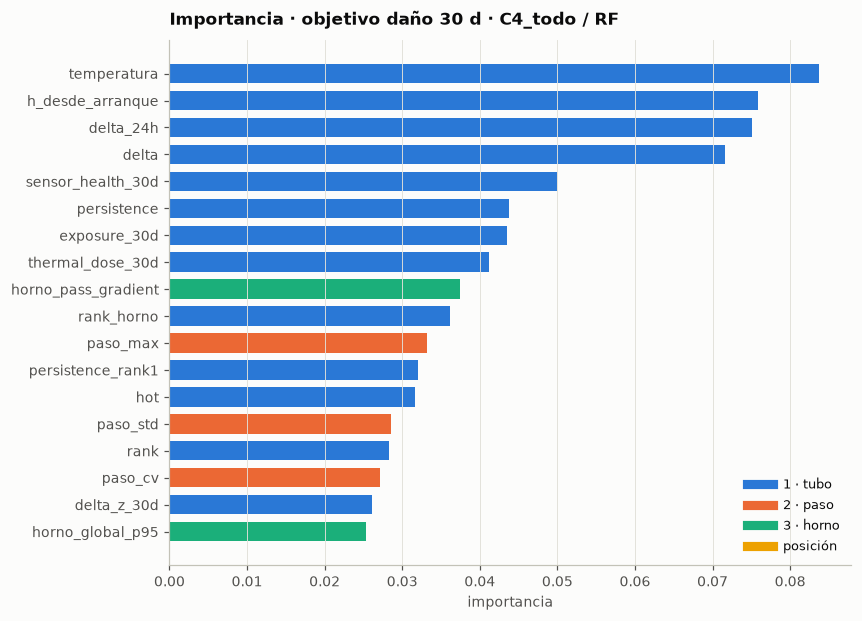

importancia acumulada por nivel de la jerarquía:
1 · tubo     0.641
2 · paso     0.189
3 · horno    0.130
posición     0.039


In [8]:
# El desglose por nivel solo tiene sentido sobre un caso que contenga los tres, así que se
# mira C4_todo. El ganador en MAE se imprime aparte: que gane un caso más chico ES el hallazgo.
CASO_IMP = "C4_todo"
mejor    = RES["dano_30d"].iloc[0]
fila_imp = RES["dano_30d"].query("caso == @CASO_IMP").iloc[0]
m, feats = AJUSTADOS[("dano_30d", CASO_IMP, fila_imp.modelo)]
imp = pd.Series(m.feature_importances_, index=feats).sort_values(ascending=False)
print(f"ganador en MAE : {mejor.caso} / {mejor.modelo} ({mejor.n_feats} features, "
      f"{mejor['mejora_%']:+.1f}% vs baseline)")
print(f"caso analizado : {CASO_IMP} / {fila_imp.modelo} ({fila_imp.n_feats} features, "
      f"{fila_imp['mejora_%']:+.1f}%)\n")

def nivel_de(f):
    if f.startswith("horno_"): return "3 · horno"
    if f.startswith("paso_"):  return "2 · paso"
    if f in POS:               return "posición"
    return "1 · tubo"

COLOR_NIV = {"1 · tubo": "#2a78d6", "2 · paso": "#eb6834",
             "3 · horno": "#1baf7a", "posición": "#eda100"}
top = imp.head(18)[::-1]
fig, ax = plt.subplots(figsize=(8, 6.2))
ax.barh(top.index, top.values, color=[COLOR_NIV[nivel_de(f)] for f in top.index], height=0.72)
ax.set_xlabel("importancia"); ax.grid(axis="y", alpha=0)
ax.set_title(f"Importancia · objetivo daño 30 d · {CASO_IMP} / {fila_imp.modelo}",
             loc="left", fontsize=11, fontweight="bold", pad=10)
ax.legend(handles=[plt.Line2D([], [], color=c, lw=6, label=n) for n, c in COLOR_NIV.items()],
          loc="lower right", frameon=False, fontsize=8.5)
plt.savefig(REPORTES / "fig_importancia.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

print("importancia acumulada por nivel de la jerarquía:")
print(imp.groupby(imp.index.map(nivel_de)).sum().sort_values(ascending=False).round(3).to_string())

### 6.1 Correlación entre las features y su peso en el modelo

Correlación de Spearman entre las 36 features de `C4_todo` (las mismas del desglose de
importancia de arriba), con las filas y columnas **ordenadas de mayor a menor importancia**: así
el heatmap y el panel de barras de la derecha quedan alineados fila por fila, y se puede leer
directo si una feature con importancia alta arrastra a otras muy correlacionadas (candidatas a
podar) o si es información genuinamente distinta.

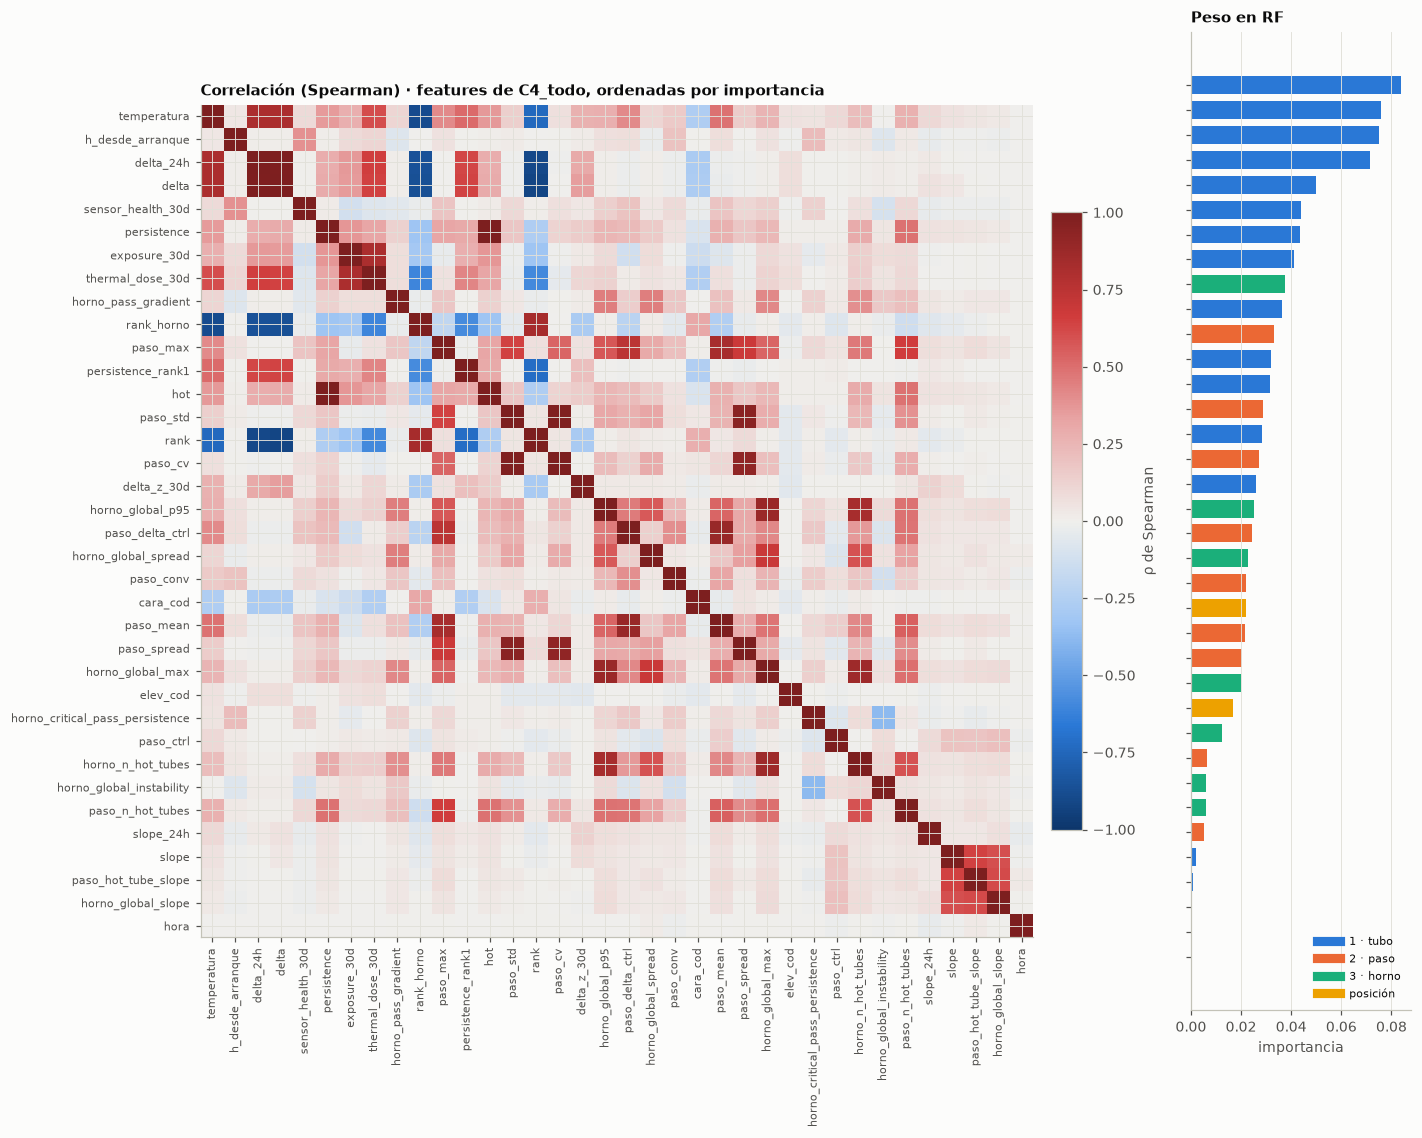

19 pares con |ρ| >= 0.8 entre las 36 features de C4_todo (candidatos a redundancia — ver columnas imp_1/imp_2 para decidir cuál podar):


,feature_1,feature_2,rho,imp_1,imp_2
192,persistence,hot,1.000,0.044,0.032
75,delta_24h,delta,0.987,0.075,0.072
483,paso_std,paso_cv,0.982,0.029,0.027
491,paso_std,paso_spread,0.945,0.029,0.020
563,paso_cv,paso_spread,0.921,0.027,0.020
122,delta,rank,-0.915,0.072,0.028
86,delta_24h,rank,-0.903,0.075,0.028
670,paso_delta_ctrl,paso_mean,0.889,0.024,0.022
9,temperatura,rank_horno,-0.884,0.084,0.036
636,horno_global_p95,horno_global_max,0.876,0.025,0.020


In [9]:
from matplotlib.colors import LinearSegmentedColormap

CMAP_DIV = LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#e8a3a3", "#d03b3b", "#7d1f1f"])

feats_corr = imp.index.tolist()                          # las 36 de C4_todo, ya ordenadas por importancia
n = len(feats_corr)
base_corr = usable[feats_corr].dropna()
muestra = base_corr.sample(min(200_000, len(base_corr)), random_state=SEMILLA)
corr = muestra.corr(method="spearman").loc[feats_corr, feats_corr]

fig, (axc, axi) = plt.subplots(1, 2, figsize=(13, 10.5), gridspec_kw={"width_ratios": [4, 1]})

im = axc.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
axc.set_xticks(range(n)); axc.set_xticklabels(feats_corr, rotation=90, fontsize=7)
axc.set_yticks(range(n)); axc.set_yticklabels(feats_corr, fontsize=7)
axc.set_title(f"Correlación (Spearman) · features de {CASO_IMP}, ordenadas por importancia",
              loc="left", fontsize=10, fontweight="bold")
plt.colorbar(im, ax=axc, fraction=0.035, pad=0.02, label="ρ de Spearman")

axi.barh(range(n), imp.loc[feats_corr].values,
         color=[COLOR_NIV[nivel_de(f)] for f in feats_corr], height=0.72)
axi.set_yticks(range(n)); axi.set_yticklabels([])
axi.invert_yaxis()                                        # fila 0 (más importante) arriba, igual que el heatmap
axi.set_xlabel("importancia")
axi.set_title(f"Peso en {fila_imp.modelo}", loc="left", fontsize=10, fontweight="bold")
axi.grid(axis="y", alpha=0)
axi.legend(handles=[plt.Line2D([], [], color=c, lw=6, label=k) for k, c in COLOR_NIV.items()],
           loc="lower right", frameon=False, fontsize=7.5)

plt.tight_layout()
plt.savefig(REPORTES / "fig_correlacion_importancia.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

# ---------- pares redundantes: alta correlación entre dos features usadas ----------
mask_sup = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pares = corr.where(mask_sup).stack().rename("rho").reset_index()
pares.columns = ["feature_1", "feature_2", "rho"]
pares["imp_1"] = pares.feature_1.map(imp).round(3)
pares["imp_2"] = pares.feature_2.map(imp).round(3)
altos = pares[pares.rho.abs() >= 0.8].sort_values("rho", key=lambda s: s.abs(), ascending=False)
altos.to_csv(REPORTES / "correlaciones_altas_C4_todo.csv", index=False)

print(f"{len(altos)} pares con |ρ| >= 0.8 entre las {n} features de {CASO_IMP} "
      f"(candidatos a redundancia — ver columnas imp_1/imp_2 para decidir cuál podar):")
altos.round(3)

## 7. Proyección de daño a octubre de 2028

Acá se responde la pregunta. El criterio es **Robinson**: el daño acumulado $D=\sum t_i/t_{r,i}$
llega a 1 en la rotura por fluencia. La proyección es aritmética simple sobre la tasa medida:

$$D_{2028} = D_{\text{hoy}} + \dot{D} \cdot h_{\text{operación restantes}}$$

La tasa $\dot D$ **no se extrapola de la tendencia**, se recalcula: se toma la distribución real
de temperaturas de cada tubo en los últimos 12 meses de operación, se la corre $\Delta T$, y se
evalúa el daño horario a esa temperatura. Así el escenario "+20 °C" es exacto y no una regla de
tres — el daño es exponencial en la temperatura, así que una regla de tres daría cualquier cosa.

Los escenarios cubren desde "sigue como hoy" hasta una degradación fuerte por coquización. La
pregunta que cierra la sección es la inversa y es la más útil: **¿cuántos grados de más
tendría que sostener el tubo crítico para que el criterio obligue a parar antes de oct-2028?**

In [10]:
# ---------------- configuración editable ----------------
FECHA_META = pd.Timestamp("2028-10-01")
D_LIMITE   = 1.00        # Robinson: 1.0 = rotura. Criterio conservador de planta: 0.5
MESES_REF  = 12          # ventana para la temperatura representativa de cada tubo
ESCENARIOS = {"actual": 0, "+10 °C": 10, "+20 °C": 20, "+30 °C": 30}

ult   = panel.ts.max()
ref   = usable[usable.ts >= ult - pd.DateOffset(months=MESES_REF)]
disp  = nivel3[nivel3.ts >= ult - pd.DateOffset(months=MESES_REF)].run.mean()
h_fut = (FECHA_META - ult).days * 24 * disp
D_hoy = panel.groupby("tubo", observed=True).thermal_dose.max()

def tasa_horaria(temps, dT):
    """Daño medio por hora de operación si esa distribución de T se corre dT grados."""
    return float((1.0 / t_ruptura(temps.to_numpy() + dT)).mean())

proy = pd.DataFrame({"paso": [TUBO_PASO[t] for t in D_hoy.index], "D_hoy": D_hoy})
for esc, dT in ESCENARIOS.items():
    proy[esc] = D_hoy + ref.groupby("tubo", observed=True).temperatura.apply(
        lambda s, d=dT: tasa_horaria(s, d)) * h_fut

print(f"último dato        : {ult:%Y-%m-%d}")
print(f"horizonte a la meta: {(FECHA_META-ult).days/365.25:.2f} años")
print(f"disponibilidad     : {disp*100:.1f}%  ->  {h_fut:,.0f} h de operación hasta {FECHA_META:%b-%Y}")
print(f"criterio           : D >= {D_LIMITE}\n")
print("D proyectado a oct-2028 por escenario — 8 tubos más críticos:")
print(proy.nlargest(8, "+30 °C").round(4).to_string())

último dato        : 2026-01-30
horizonte a la meta: 2.67 años
disponibilidad     : 78.8%  ->  18,416 h de operación hasta Oct-2028
criterio           : D >= 1.0

D proyectado a oct-2028 por escenario — 8 tubos más críticos:
     paso   D_hoy  actual  +10 °C  +20 °C  +30 °C
tubo                                             
18D    P2  0.1515  0.1549  0.1580  0.1640  0.1749
31B    P3  0.1281  0.1322  0.1360  0.1431  0.1561
18B    P2  0.1158  0.1171  0.1184  0.1209  0.1254
17C    P1  0.1088  0.1089  0.1090  0.1092  0.1096
18F    P2  0.0982  0.0983  0.0984  0.0986  0.0989
17F    P1  0.0267  0.0304  0.0341  0.0411  0.0543
31E    P3  0.0093  0.0150  0.0202  0.0299  0.0476
32C    P4  0.0346  0.0362  0.0378  0.0407  0.0464


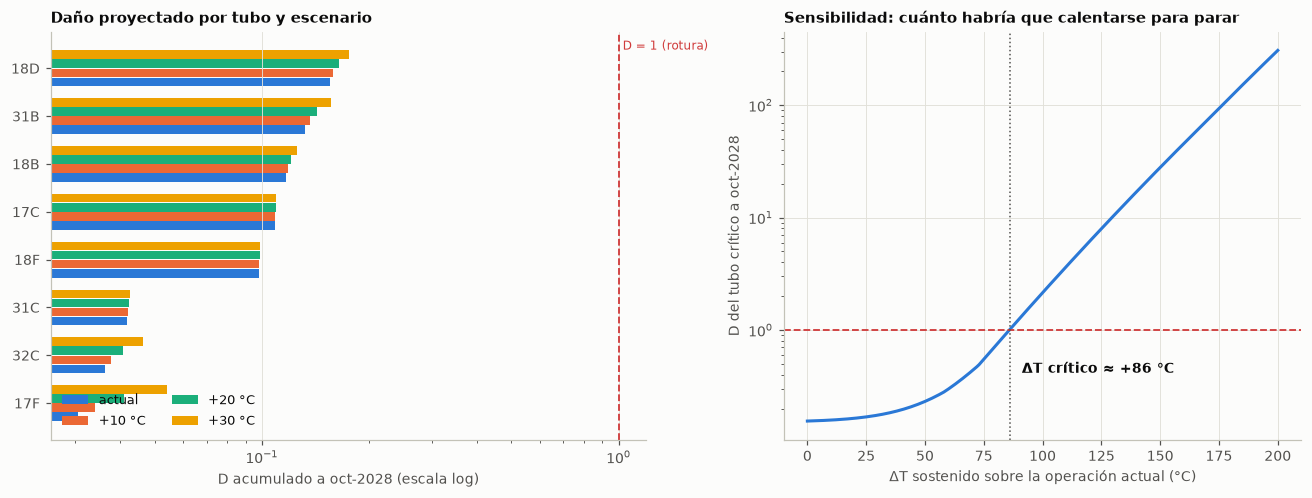

tubo crítico            : 18D (paso P2)
D hoy                   : 0.1515
D a oct-2028 (actual)   : 0.1549
D a oct-2028 (+30 °C)   : 0.1749
ΔT crítico              : +86 °C sostenidos durante los 2.7 años

VEREDICTO: NO se requiere parada por fluencia en oct-2028 al ritmo actual (margen 6x sobre el criterio de Robinson).


In [11]:
# ¿cuántos grados de más obligarían a parar antes de la meta?
grados = np.arange(0, 201, 1.0)
peor = pd.Series({g: max(D_hoy[t] + tasa_horaria(s, g) * h_fut
                         for t, s in ref.groupby("tubo", observed=True).temperatura)
                  for g in grados})
cruce = peor[peor >= D_LIMITE]
dT_critico = cruce.index[0] if len(cruce) else np.nan

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})

top8 = proy.nlargest(8, "actual").iloc[::-1]
y = np.arange(len(top8))
for i, (esc, col) in enumerate(zip(ESCENARIOS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"])):
    a1.barh(y + (i - 1.5) * 0.19, top8[esc], height=0.18, color=col, label=esc)
a1.set_yticks(y, top8.index)
a1.set_xscale("log"); a1.set_xlabel("D acumulado a oct-2028 (escala log)")
a1.axvline(D_LIMITE, color="#d03b3b", lw=1.2, ls="--")
a1.text(D_LIMITE, len(top8)-0.4, f" D = {D_LIMITE:.0f} (rotura)", color="#d03b3b", fontsize=8, va="top")
a1.grid(axis="y", alpha=0)
a1.set_title("Daño proyectado por tubo y escenario", loc="left", fontsize=10, fontweight="bold")
a1.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=2)

a2.plot(grados, peor.values, color="#2a78d6", lw=2)
a2.axhline(D_LIMITE, color="#d03b3b", lw=1.2, ls="--")
a2.set_yscale("log"); a2.set_xlabel("ΔT sostenido sobre la operación actual (°C)")
a2.set_ylabel("D del tubo crítico a oct-2028")
if np.isfinite(dT_critico):
    a2.axvline(dT_critico, color="#52514e", lw=1, ls=":")
    a2.annotate(f"ΔT crítico ≈ +{dT_critico:.0f} °C", (dT_critico, D_LIMITE),
                xytext=(8, -28), textcoords="offset points", fontsize=9, fontweight="bold")
a2.set_title("Sensibilidad: cuánto habría que calentarse para parar", loc="left",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTES / "fig_proyeccion_2028.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

peor_tubo = proy["actual"].idxmax()
print(f"tubo crítico            : {peor_tubo} (paso {TUBO_PASO[peor_tubo]})")
print(f"D hoy                   : {D_hoy[peor_tubo]:.4f}")
print(f"D a oct-2028 (actual)   : {proy.loc[peor_tubo,'actual']:.4f}")
print(f"D a oct-2028 (+30 °C)   : {proy.loc[peor_tubo,'+30 °C']:.4f}")
print(f"ΔT crítico              : +{dT_critico:.0f} °C sostenidos durante los {(FECHA_META-ult).days/365.25:.1f} años")
print(f"\nVEREDICTO: {'PARADA REQUERIDA' if proy['actual'].max() >= D_LIMITE else 'NO se requiere parada'} "
      f"por fluencia en oct-2028 al ritmo actual "
      f"(margen {D_LIMITE/proy['actual'].max():.0f}x sobre el criterio de Robinson).")

## 8. Figuras y tablas para el informe

Genera los artefactos que consume `reportes/informe_modelos.md`: las tablas de resultados en
CSV y cuatro figuras que muestran **RF y XGBoost por separado**, panel a panel, para poder
compararlos sin que uno tape al otro.

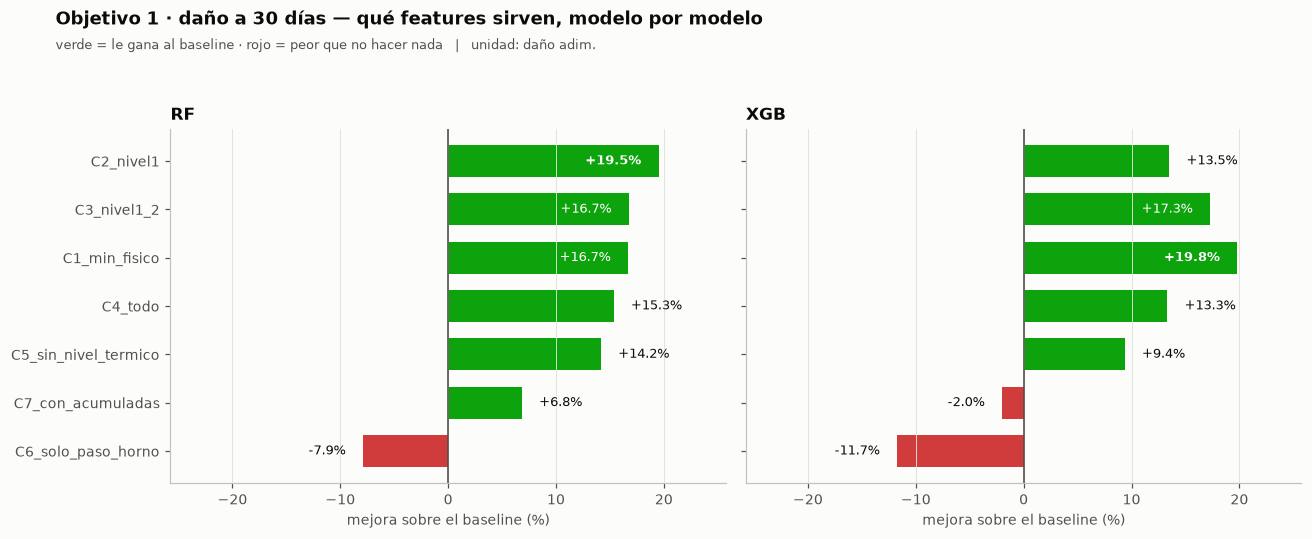

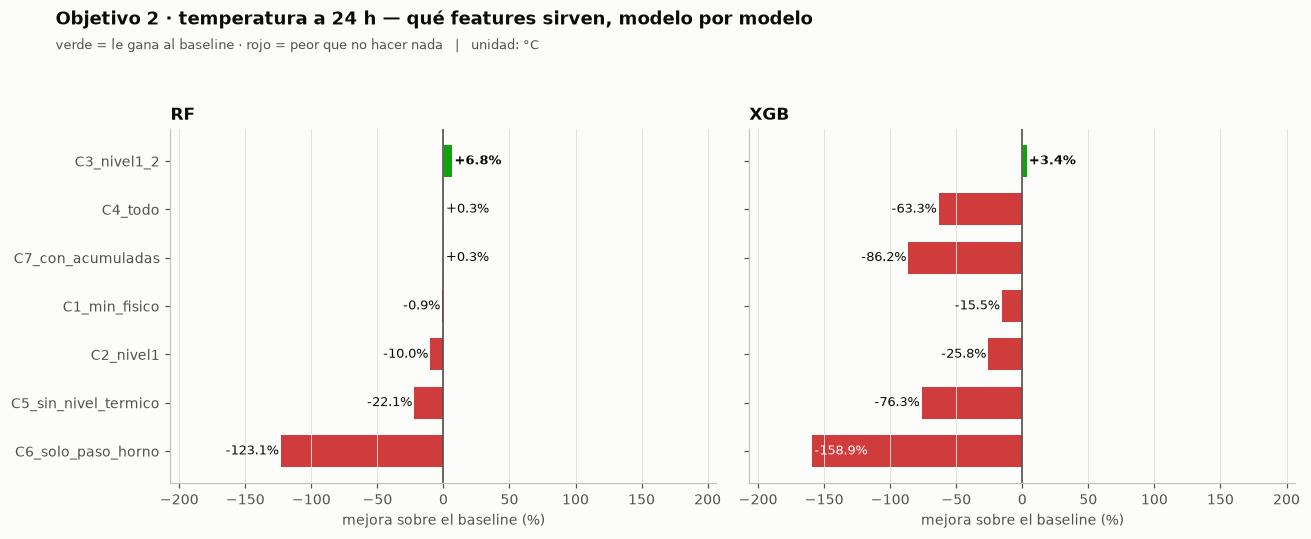

In [12]:
GRIS = "#898781"
BUENO, MALO = "#0ca30c", "#d03b3b"

# ---------- tablas ----------
tabla = pd.concat([RES[o].assign(objetivo=o) for o in OBJETIVOS])[
    ["objetivo","caso","modelo","n_feats","MAE","MAE_base","mejora_%","R2","seg"]]
tabla.to_csv(REPORTES / "resultados_modelos.csv", index=False)
proy.round(6).to_csv(REPORTES / "proyeccion_2028.csv")

# ---------- 1-2. comparación de casos, un panel por modelo ----------
def fig_casos(obj, archivo, titulo, unidad):
    d = RES[obj]
    orden = (d[d.modelo == "RF"].set_index("caso")["mejora_%"].sort_values().index.tolist())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharex=True)
    lim = max(abs(d["mejora_%"]).max() * 1.30, 25)
    for ax, mod in zip(axes, ["RF", "XGB"]):
        s = d[d.modelo == mod].set_index("caso")["mejora_%"].reindex(orden)
        ax.barh(range(len(s)), s.values, height=0.66,
                color=[BUENO if v >= 0 else MALO for v in s.values])
        ax.set_yticks(range(len(s)), s.index)
        ax.axvline(0, color="#52514e", lw=1.1)
        for i, v in enumerate(s.values):
            dentro = abs(v) > 0.62 * lim          # si no entra afuera, va adentro de la barra
            off    = -1.6 if dentro else 1.6
            ax.text(v + np.sign(v) * off, i, f"{v:+.1f}%", va="center",
                    ha=("right" if v >= 0 else "left") if dentro else
                       ("left" if v >= 0 else "right"),
                    fontsize=8.5, color="#ffffff" if dentro else TINTA,
                    fontweight="bold" if v == s.max() else "normal")
        ax.set_xlim(-lim, lim); ax.grid(axis="y", alpha=0)
        ax.set_xlabel("mejora sobre el baseline (%)")
        ax.set_title(mod, loc="left", fontsize=11, fontweight="bold")
    axes[1].tick_params(labelleft=False)
    fig.suptitle(titulo, x=0.045, ha="left", fontsize=12, fontweight="bold", y=1.10)
    fig.text(0.045, 1.02, f"verde = le gana al baseline · rojo = peor que no hacer nada"
                          f"   |   unidad: {unidad}", fontsize=8.5, color=TINTA2)
    plt.tight_layout()
    plt.savefig(REPORTES / archivo, dpi=150, bbox_inches="tight", facecolor=SUP)
    plt.show()

fig_casos("dano_30d", "fig_casos_dano.png",
          "Objetivo 1 · daño a 30 días — qué features sirven, modelo por modelo", "daño adim.")
fig_casos("T_24h", "fig_casos_T24h.png",
          "Objetivo 2 · temperatura a 24 h — qué features sirven, modelo por modelo", "°C")

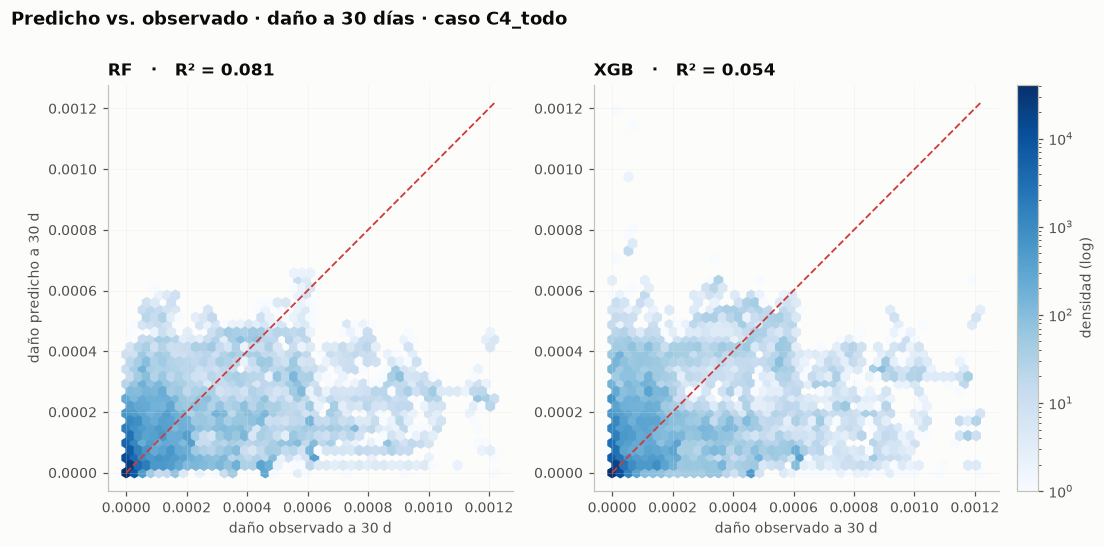

In [13]:
# ---------- 3. predicho vs observado, un panel por modelo ----------
CASO_PVO = "C4_todo"
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, mod in zip(axes, ["RF", "XGB"]):
    yb, pr, _ = PRED[("dano_30d", CASO_PVO, mod)]
    top = np.quantile(yb, 0.995)
    m = (yb <= top) & (pr <= top)
    hb = ax.hexbin(yb[m], pr[m], gridsize=45, bins="log", cmap="Blues", mincnt=1,
                   extent=(0, top, 0, top))
    ax.plot([0, top], [0, top], color="#d03b3b", lw=1.2, ls="--")
    r2 = RES["dano_30d"].query("caso == @CASO_PVO and modelo == @mod").R2.iloc[0]
    ax.set_xlabel("daño observado a 30 d"); ax.set_title(
        f"{mod}   ·   R² = {r2:.3f}", loc="left", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("daño predicho a 30 d")
plt.colorbar(hb, ax=axes, fraction=0.03, pad=0.02, label="densidad (log)")
fig.suptitle(f"Predicho vs. observado · daño a 30 días · caso {CASO_PVO}",
             x=0.045, ha="left", fontsize=12, fontweight="bold", y=1.02)
plt.savefig(REPORTES / "fig_pred_vs_obs.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

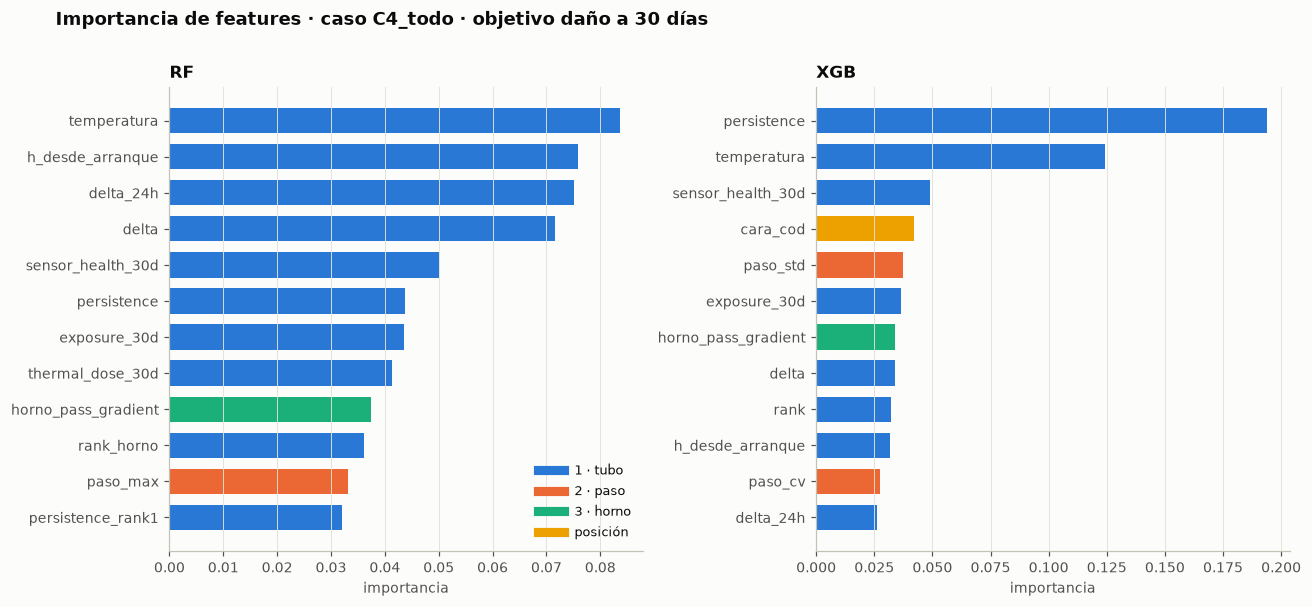

importancia acumulada por nivel de la jerarquía:
              RF    XGB
1 · tubo   0.641  0.625
2 · paso   0.189  0.168
3 · horno  0.130  0.140
posición   0.039  0.066

artefactos en reportes/: resultados_modelos.csv, proyeccion_2028.csv, importancia_por_nivel.csv + 5 figuras


In [14]:
# ---------- 4. importancia comparada RF vs XGB ----------
COLOR_NIV = {"1 · tubo": "#2a78d6", "2 · paso": "#eb6834",
             "3 · horno": "#1baf7a", "posición": "#eda100"}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
resumen = {}
for ax, mod in zip(axes, ["RF", "XGB"]):
    mm, ff = AJUSTADOS[("dano_30d", "C4_todo", mod)]
    s = pd.Series(mm.feature_importances_, index=ff).sort_values(ascending=False)
    resumen[mod] = s.groupby(s.index.map(nivel_de)).sum()
    t = s.head(12)[::-1]
    ax.barh(t.index, t.values, color=[COLOR_NIV[nivel_de(f)] for f in t.index], height=0.7)
    ax.set_xlabel("importancia"); ax.grid(axis="y", alpha=0)
    ax.set_title(mod, loc="left", fontsize=11, fontweight="bold")
axes[0].legend(handles=[plt.Line2D([], [], color=c, lw=6, label=n) for n, c in COLOR_NIV.items()],
               loc="lower right", frameon=False, fontsize=8.5)
fig.suptitle("Importancia de features · caso C4_todo · objetivo daño a 30 días",
             x=0.045, ha="left", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTES / "fig_importancia_rf_xgb.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

imp_niv = pd.DataFrame(resumen).fillna(0).round(3)
imp_niv.to_csv(REPORTES / "importancia_por_nivel.csv")
print("importancia acumulada por nivel de la jerarquía:")
print(imp_niv.to_string())
print(f"\nartefactos en {REPORTES.name}/: resultados_modelos.csv, proyeccion_2028.csv, "
      f"importancia_por_nivel.csv + 5 figuras")

## 9. Lectura de los resultados

**Sobre el modelo**

- En **daño a 30 d** los modelos le ganan al baseline, pero con R² bajo. Es esperable: el daño
  futuro depende de decisiones operativas (carga, fuego, campaña) que no están en las features.
  Un baseline honesto que mejora ~20 % sobre "el mes que viene será como el anterior" es un
  resultado utilizable para estimar la tasa, que es para lo que se lo usa acá.
- En **temperatura a 24 h** cuesta ganarle a la persistencia, y la sección 18.1 muestra por qué:
  la mitad del error vive en el 3 % de filas que son arranques y paradas. Para mejorar ahí hace
  falta información de proceso que hoy no está en el dataset (consignas, caudal, composición de
  carga), no más features térmicas.
- Los casos muestran dónde está el aporte de cada nivel de la jerarquía. Comparar `C2` con `C3`
  y `C4` dice cuánto suman paso y horno; `C6` dice cuánto se puede reconstruir de un tubo sin
  medirlo — que es la respuesta para los termopares fuera de servicio como `18A`.

**Sobre 2028**

- El resultado al ritmo actual tiene un margen enorme contra el criterio de Robinson. Eso **no
  significa que el horno esté sano**: significa que *por fluencia acumulada* no llega al límite.
  Los modos de falla que sí podrían forzar una parada —coquización, obstrucción, falla de un
  quemador— se ven en `spread`, `delta_z_30d` y `persistence`, no en `thermal_dose`.
- El número accionable es el **ΔT crítico**: dice cuánto margen térmico hay antes de que el
  criterio cambie de signo. Es lo que hay que monitorear mes a mes contra `global_p95`.
- La proyección hereda todos los supuestos del modelo de creep: el anclaje Larson-Miller a
  705 °C / 100.000 h, la tensión de aro calculada con espesor nominal (sin descuento por
  corrosión ni adelgazamiento medido) y la hipótesis de que la operación futura se parece a la
  de los últimos 12 meses. Con espesor real medido en la próxima inspección, `SIGMA_H` cambia y
  toda la proyección se recalcula sola.

**Para editar**

- Otro corte de train/test: `TRAIN_INI` / `TRAIN_FIN` / `TEST_INI`, celda 3.
- Otro caso de features: agregar una entrada al dict `CASOS`, celda 4. Nada más.
- Otro modelo: agregarlo a `MODELOS` con la misma interfaz (`lambda: Estimador(...)`), celda 3.
- Criterio más conservador: `D_LIMITE = 0.5`, celda 7. Otra fecha meta: `FECHA_META`.
- Entrenar con todos los datos en vez de 1 de cada 4 horas: `SUBM = 1`, celda 3.